Outer Model: A regular stochastic volatility model

$$\frac{dS_t}{S_t} = \mu dt+\sqrt{\nu_t} dW^S_t$$

and

$$d\nu_t= \kappa(\theta-\nu_t)dt + \xi \sqrt{\nu_t} dW^\nu_t$$

with the two Wiener processes having correlation $\rho$

This is the long term effects we want to see in our model

However, let's say that we *know* there is going to be some expected vol at the beginning and end of market close.

Further, there are going to be random volatility shocks that are uncorrelated from the vol's Wiener process, likely due to significant market related effects. 

Let's upgrade the model.

First consider

$$d\nu_t= \kappa(\theta(t)-\nu_t)dt + \xi \sqrt{\nu_t} dW^\nu_t$$

Now our mean reverting vol is time dependent, which is what we want to include for market open and market close. One can calculate this by finding the average volatility of a minute time stamp across multiple days for a specific underlying.


However, we want some more sophisticated behavior to occur on short time scales, say $\tau$, i.e. $t \sim O(\varepsilon)$. More rigorously, if a shock occurs at time $t_k$, then we have
$$\tau = \frac{t - t_k}{\varepsilon}$$

Consider

$$d\nu_\tau= \alpha(\tau)d\tau + \xi \sqrt{\nu_\tau} \beta(\tau) dW^\nu_\tau$$

where
$$\alpha(\tau) = A e^{-\gamma\tau}\quad \quad \beta(\tau) = B e^{-\gamma\tau}$$



For time scales $t$ (since $d\tau =\frac{1}{\varepsilon} dt $)

$$d\nu_t = \frac{1}{\varepsilon}A e^{-\gamma\frac{t-t_k}{\varepsilon}}dt + \xi \sqrt{\nu_t}\frac{1}{\sqrt\varepsilon} Be^{-\gamma\frac{t-t_k}{\varepsilon}} dW^\nu_t$$

which is the inner component of the model


Thus, we can combine our outer and inner model:

$$d\nu_t = (\kappa(\theta(t)-\nu_t)+\frac{1}{\varepsilon}A e^{-\gamma\frac{t-t_k}{\varepsilon}})dt + \xi \sqrt{\nu_t}(1+\frac{1}{\sqrt{\varepsilon}}Be^{-\gamma\frac{t-t_k}{\varepsilon}}) dW^\nu_t$$



However, this is only for one spike. So we can generate an aribtrary number of spikes via a Poisson Process. Consider a Poisson Process $\{N_t\}_{t<\text{one day}}$ with associated jump times $\{{t_k}_i\}$. Then our model is:

$$d\nu_t = (\kappa(\theta(t)-\nu_t)+\sum_{{t_k}_i<t}[\frac{1}{\varepsilon}A e^{-\gamma\frac{t-{t_k}_i}{\varepsilon}}])dt + \xi \sqrt{\nu_t}(1+\sum_{{t_k}_i<t}[\frac{1}{\sqrt{\varepsilon}}Be^{-\gamma\frac{t-{t_k}_i}{\varepsilon}}]) dW^\nu_t$$


Finally, the contribution of the spikes can be treated as a sum of decaying Poisson processes. This provides us with:

$$dY_t = -\frac{\gamma}{\varepsilon} Y_tdt + dN_t$$

$$d\nu_t = (\kappa(\theta(t)-\nu_t)+\frac{A}{\varepsilon}Y_t)dt + \xi\sqrt{\nu_t}(1+\frac{B}{\sqrt{\varepsilon}}Y_t) dW^\nu_t$$

$$\frac{dS_t}{S_t} = \mu dt+\sqrt{\nu_t} dW^S_t$$


In [699]:
import numpy as np
from numba import njit

@njit
def generate_dws_dwt(dt, rho):
    z1 = np.random.normal()
    z2 = np.random.normal()

    dw_v = np.sqrt(dt) * z1
    dw_s = np.sqrt(dt) * (rho*z1 + np.sqrt(1-rho**2)*z2)
    return dw_s,dw_v

@njit
def simulate_full_system(
    S_inital = 100,
    T=390,           # trading minutes in a day
    dt=.1,           # 1 minute step
    eps=1E-3,        # boundary thickness
    kappa=1,         # variance mean reversion speed
    theta=1.5e-7,    # long-run variance
    xi=3e-5,         # vol-of-vol
    gamma=1E-1,      # price impact / drift adjustment
    A=5E-10,       # jump size mean
    B=2E-3,         # jump size std
    mu=.07 / (252*6.5*60),         # drift (intraday ≈ 0)
    rho=0,       # leverage effect
    lambda_jump= 1 / (6.5*60)  # jumps per minute (~8 per day)
):
    n_steps = int(T / dt)
    S = np.zeros(n_steps)
    nu = np.zeros(n_steps)
    Y = np.zeros(n_steps)
    r = np.zeros(n_steps)
    jump_times = np.full(n_steps, np.nan)  # nan = no jump
    t_list = np.arange(0, T, dt)
    
    S[0] = S_inital
    nu[0] = theta
    Y[0] = 0.0
    
    # Pre-calculate noise scaling constant
    # noise_const = np.sqrt(eps * B**2 / A**2) if A != 0 else 0
    
    for t in range(n_steps - 1):
        # 1. Handle Poisson Jumps for dN_t
        # Prob of jump in dt is lambda * dt
        jump = 0.0
        if np.random.random() < lambda_jump * dt:
            jump = 1 
            jump_times[t] = S[t] 
            # print(f"Jump at time {t}")
            
        # 2. Update Y (The Shock Variable)
        # dY = -(gamma/eps)*Y*dt + (A/eps)*dN
        
        # 3. Generate Correlated Brownian Motion
        dw_s, dw_v = generate_dws_dwt(dt, rho)
                
        # Y update
        Y[t+1] = Y[t] + (-gamma * Y[t]) * dt + jump

        # variance
        v_pos = max(nu[t], 0.0)

        sigma_v = xi * np.sqrt(v_pos) * (1.0 + B * Y[t] / np.sqrt(eps))

        nu[t+1] = nu[t] + (kappa * (theta - nu[t]) + A* Y[t] / eps) * dt + sigma_v * dw_v
        while nu[t+1] < 0:
            dw_s, dw_v = generate_dws_dwt(dt, rho)
            nu[t+1] = nu[t] + (kappa * (theta - nu[t]) + A* Y[t] / eps) * dt + sigma_v * dw_v
            # print(nu[t+1])

        # price
        S[t+1] = S[t] * (1 + (mu)*dt + np.sqrt(v_pos)*dw_s)
        r[t] = (mu)*dt + np.sqrt(v_pos)*dw_s
        # print("S : ",S[t], "r : ",1-np.exp((mu - 0.5*v_pos)*dt + np.sqrt(v_pos)*dw_s), "var : ",v_pos, "walk : ",dw_s)
        
    return S, nu, Y, r, t_list, jump_times

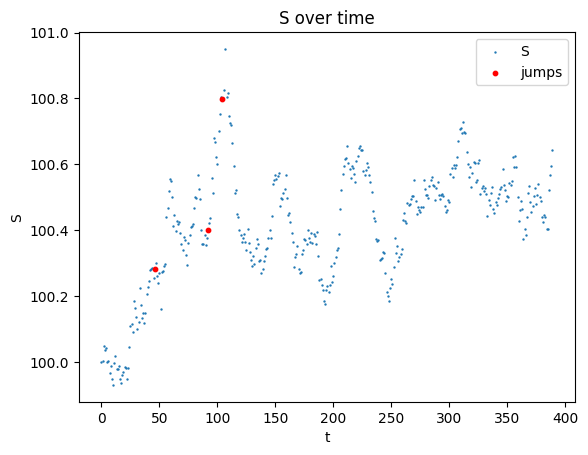

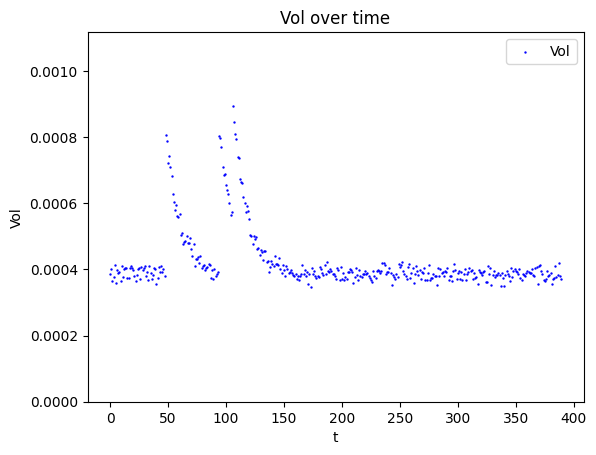

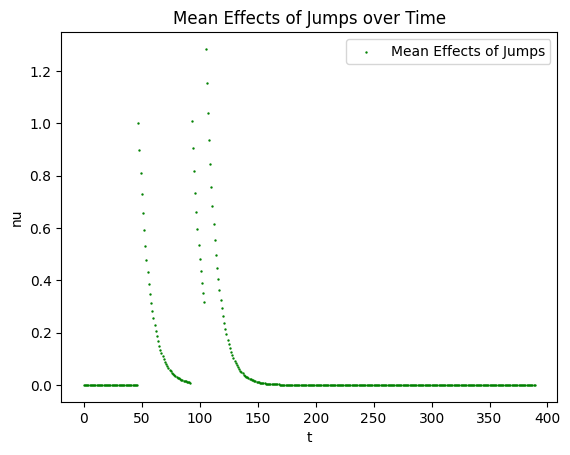

In [741]:
import matplotlib.pyplot as plt

# Run your simulation
S, nu, Y, r, t, jump_times = simulate_full_system(dt=1)

# First plot: S vs t
plt.figure()
plt.scatter(t, S, s=0.5, label='S')
plt.scatter(t, jump_times, s=10, c='red', label='jumps')
plt.xlabel('t')
plt.ylabel('S')
plt.title('S over time')
plt.legend()

# Second plot: nu vs t
plt.figure()
plt.scatter(t, np.sqrt(nu), s=0.5, c='blue', label='Vol')
plt.xlabel('t')
plt.ylabel('Vol')
plt.ylim(0, max(np.sqrt(nu))*1.25)
plt.title('Vol over time')
plt.legend()

plt.figure()
plt.scatter(t, Y, s=0.5, c='green', label='Mean Effects of Jumps')
plt.xlabel('t')
plt.ylabel('nu')
plt.title('Mean Effects of Jumps over Time')
plt.legend()

plt.show()


In [736]:
from tqdm import tqdm
final_vals = np.zeros(1000000)
final_var = np.zeros(1000000)
for i in tqdm(range(1000000)):
    j = simulate_full_system(dt =1, rho = .3)
    final_vals[i] = j[0][-1]
    final_var[i] = j[1][-1]

100%|██████████| 1000000/1000000 [00:40<00:00, 24404.32it/s]


In [737]:
final_vals.shape

(1000000,)

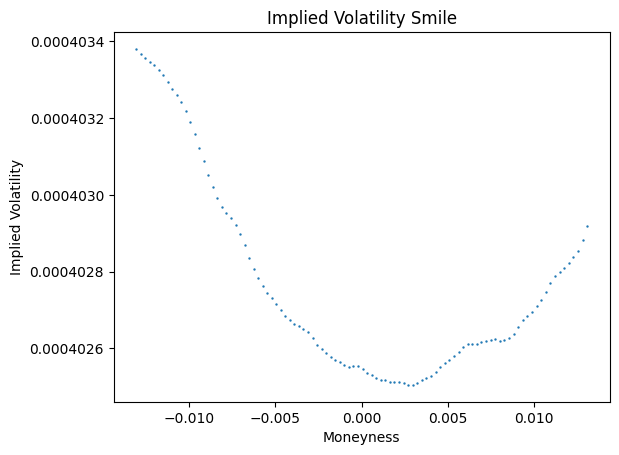

In [738]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq

# Inputs (make sure these already exist)
S0 = np.mean(final_vals)  # or your actual initial stock price
r = 0.0                   # risk-free rate
T = 390.0                   # maturity (adjust if needed)

# Strike grid
K_vals = np.linspace(np.percentile(final_vals, 5), np.percentile(final_vals, 95), 100)

# Monte Carlo call prices
call_prices = np.array([
    np.exp(-r*T) * np.mean(np.maximum(final_vals - K, 0))
    for K in K_vals
])

# Black–Scholes call
def bs_call(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T)/(sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

# Implied volatility solver
def implied_vol(price, S, K, T, r):
    f = lambda sigma: bs_call(S, K, T, r, sigma) - price
    try:
        return brentq(f, 1e-6, 5.0)
    except:
        return np.nan

iv_vals = np.array([
    implied_vol(p, S0, K, T, r)
    for p, K in zip(call_prices, K_vals)
])

# Plot volatility smile
plt.scatter(np.log(S0/K_vals), iv_vals, s=.5)
plt.xlabel("Moneyness")
plt.ylabel("Implied Volatility")
plt.title("Implied Volatility Smile")
plt.show()

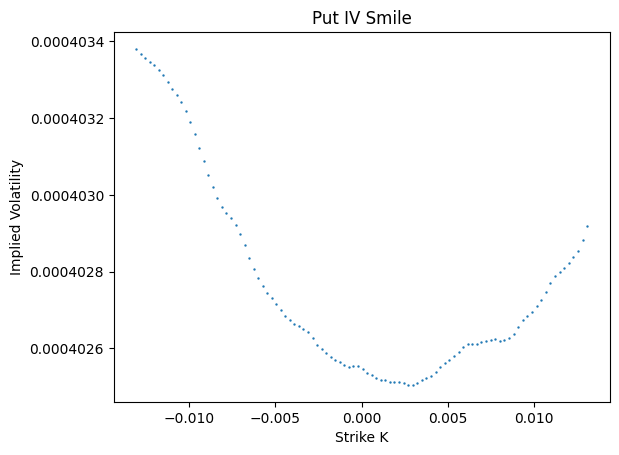

In [739]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq

K_vals = np.linspace(np.percentile(final_vals, 5), np.percentile(final_vals, 95), 100)

# Monte Carlo put prices
put_prices = np.exp(-r*T) * np.array([
    np.mean(np.maximum(K - final_vals, 0)) for K in K_vals
])

def bs_put(S0, K, r, T, sigma):
    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T)/(sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return K*np.exp(-r*T)*norm.cdf(-d2) - S0*norm.cdf(-d1)

def implied_vol_put(price, S0, K, r, T):
    f = lambda sigma: bs_put(S0, K, r, T, sigma) - price
    try:
        return brentq(f, 1e-6, 5)
    except ValueError:
        return np.nan

iv_vals = np.array([
    implied_vol_put(P, S0, K, r, T)
    for P, K in zip(put_prices, K_vals)
])

plt.scatter(np.log(S0/K_vals), iv_vals, s =.5)
plt.xlabel("Strike K")
plt.ylabel("Implied Volatility")
plt.title("Put IV Smile")
plt.show()

100%|██████████| 20/20 [03:12<00:00,  9.62s/it]


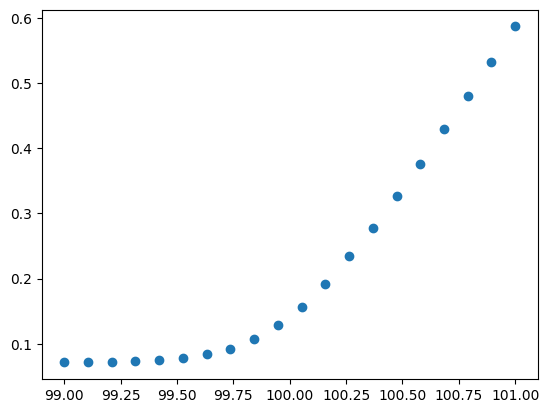

In [665]:
s_tests = np.linspace(99, 101, 20)
K = 100
pay_offs = []
for s in tqdm(s_tests):
    for i in range(50000):
        j = simulate_full_system(S_inital=s)
        final_val[i] = j[0][-1]
    final_val = np.array(final_val)
    payoff = np.mean(np.maximum(final_val - K, 0))
    pay_offs.append(payoff)

plt.scatter(s_tests, pay_offs)
plt.show()

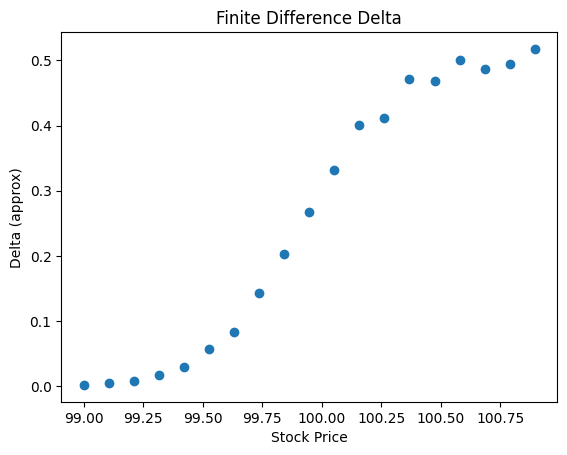

In [666]:
import numpy as np
import matplotlib.pyplot as plt

# convert lists to arrays
s_tests = np.array(s_tests)
pay_offs = np.array(pay_offs)

# finite difference approximation of Delta
sub_s = (s_tests[1:] - s_tests[:-1])
delta_approx = (pay_offs[1:] - pay_offs[:-1]) / sub_s

plt.scatter(s_tests[:-1], delta_approx)
plt.xlabel("Stock Price")
plt.ylabel("Delta (approx)")
plt.title("Finite Difference Delta")
plt.show()

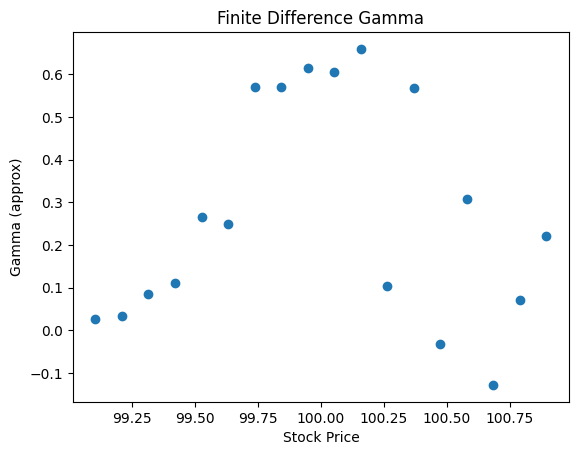

In [667]:
import numpy as np
import matplotlib.pyplot as plt


# finite difference approximation of Delta
subsub_s = (s_tests[2:] - s_tests[:-2])/2
gamma_approx = (delta_approx[1:] - delta_approx[:-1]) / subsub_s

plt.scatter(s_tests[1:-1], gamma_approx)
plt.xlabel("Stock Price")
plt.ylabel("Gamma (approx)")
plt.title("Finite Difference Gamma")
plt.show()

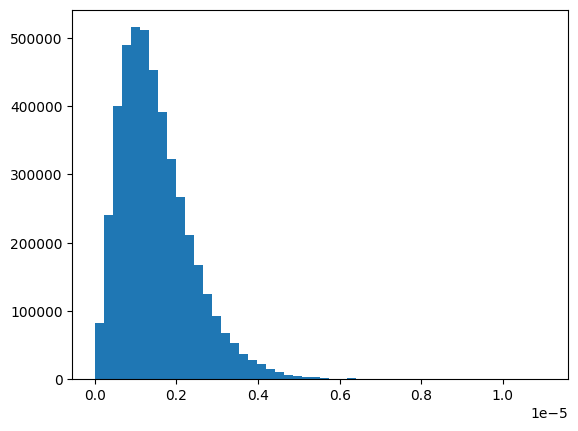

In [554]:
plt.hist(final_var, density = True, bins = 50)
plt.show()

In [572]:
import numpy as np
from arch import arch_model

# log returns
returns = np.diff(np.log(S)) #* 10000

# fit GARCH(1,1)
model = arch_model(returns, vol="Garch", p=1, q=1)
res = model.fit(disp="off")

# conditional volatility
vol = res.conditional_volatility

print("Last-minute volatility estimate:", vol[-1])

Last-minute volatility estimate: 4.370263149811778e-05


/Users/tommykornfeld/Documents/projects/m86/m86/venv/lib/python3.13/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 1.78e-09. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 1e+04 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/var/folders/80/yg22fq6568d_n43d51ww65kr0000gn/T/ipykernel_11896/722723303.py:9: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  res = model.fit(disp="off")


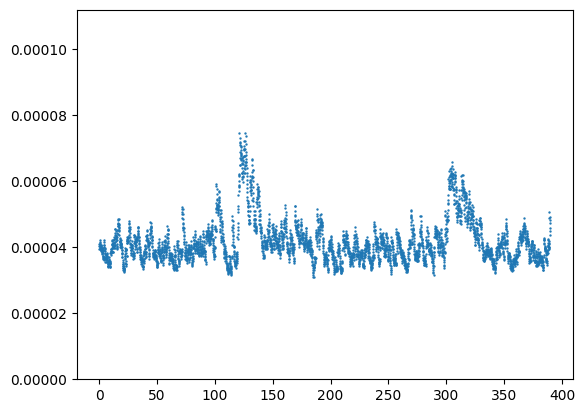

In [573]:
plt.scatter(t[:-1], vol, s=.5)
plt.ylim(0, max(vol)*1.5)
plt.show()

$$dY_t = -\frac{\gamma}{\varepsilon} Y_tdt + dN_t$$

$$d\nu_t = (\kappa(\theta(t)-\nu_t)+\frac{A}{\varepsilon}Y_t)dt + \xi\sqrt{\nu_t}(1+\frac{B}{\sqrt{\varepsilon}}Y_t) dW^\nu_t$$

$$\frac{dS_t}{S_t} = \mu dt+\sqrt{\nu_t} dW^S_t$$